In [14]:
import sys

sys.path.insert(0, '/home/caron/Bureau/Model/HexagonalScale/ST-GNN-for-wildifre-prediction/Prediction')

from config import *
from tools import *
from features import *

In [15]:

def count_pixels_in_france_deg_square(res_km=2, deg_size=0.25, lat_deg=46.5):
    """
    Calcule le nombre de pixels (res_km x res_km) dans un carré deg_size x deg_size degrés,
    situé au centre de la France (latitude 46.5°N par défaut).

    Args:
        res_km (float): Taille d’un pixel en kilomètres (par défaut 2 km).
        deg_size (float): Taille du carré en degrés (par défaut 0.25°).
        lat_deg (float): Latitude (par défaut 46.5°N, centre de la France).

    Returns:
        tuple: (n_rows, n_cols, total_pixels)
    """
    # Longueur d’un degré de latitude (quasi constant)
    km_per_deg_lat = 111.32

    # Longueur d’un degré de longitude dépendant de la latitude
    #km_per_deg_lon = 111.32 * math.cos(math.radians(lat_deg))
    km_per_deg_lon = 111.32

    # Dimensions du carré en km
    height_km = deg_size * km_per_deg_lat
    width_km = deg_size * km_per_deg_lon

    # Nombre de pixels
    n_rows = int(height_km // res_km)
    n_cols = int(width_km // res_km)
    total_pixels = n_rows * n_cols

    return n_rows, n_cols, total_pixels


def check_size(file, scale, tol):
    unique_ids = np.unique(file[(file > 0) & (~np.isnan(file))])
    size = count_pixels_in_france_deg_square(deg_size=float(f'0.{scale}'))[-1]
    max_cluster_size = size + (tol * size)
    min_cluster_size = size - (tol * size)
    for id in unique_ids:
        binary = (file == id).astype(int)
        area = binary[binary > 0].astype(int)
        area = np.sum(area)
        if area < min_cluster_size:
            print(f'{id} area {area} is less than {min_cluster_size}')
        if area > max_cluster_size:
            print(f'{id} area {area} is higher than {max_cluster_size}')

In [19]:
root_firemen = Path('/media/caron/X9 Pro1/travaille/Thèse/Model/HexagonalScale/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/raster')
root_bdiff_small = Path('/media/caron/X9 Pro1/travaille/Thèse/Model/HexagonalScale/ST-GNN-for-wildifre-prediction/Prediction/GNN/bdiff_small/firepoint/2x2/train/raster')

dept_config_daily = {
    #'Ain' :  (read_object('departement-01-ainrasterScale3_risk-size-watershed-degree-a2-r4-t0.3_node.pkl', root_firemen), 'Fire areas a 2, r 4'),
    'Doubs' : (read_object('departement-25-doubsrasterScale3_risk-size-watershed-degree-a4-r6-t0.3_node.pkl', root_firemen), 'Fire areas a 4, r 6'),
    #'Yvelines' : (read_object('departement-78-yvelinesrasterScale3_risk-size-watershed-degree-a2-r6-t0.3_node.pkl', root_firemen), 'Fire areas a 2, r 6'),
    'Bouches du rhone' : (read_object( 'departement-13-bouches-du-rhonerasterScale3_risk-size-watershed-degree-a3-r5-t0.3_node.pkl', root_bdiff_small), 'Fire areas a 3, r 5'),
    #'Herault' : (read_object('departement-34-heraultrasterScale3_risk-size-watershed-degree-a5-r6-t0.3_node.pkl', root_bdiff_small), 'Fire areas a 5, r 6'),
    }

dept_config_weekly = {
    #'Ain' :  (read_object('departement-01-ainrasterScale3_risk-size-watershed-degree-a2-r2-t0.3_node.pkl', root_firemen), 'Fire areas a 2, r 2'),
    'Doubs' : (read_object('departement-25-doubsrasterScale3_risk-size-watershed-degree-a4-r4-t0.3_node.pkl', root_firemen), 'Fire areas a 4, r 4'),
    #'Yvelines' : (read_object('departement-78-yvelinesrasterScale3_risk-size-watershed-degree-a4-r4-t0.3_node.pkl', root_firemen), 'Fire areas a 4, r 4'),
    'Bouches du rhone' : (read_object( 'departement-13-bouches-du-rhonerasterScale3_risk-size-watershed-degree-a3-r5-t0.3_node.pkl', root_bdiff_small), 'Fire areas a 3, r 5'),
    #'Herault' : (read_object('departement-34-heraultrasterScale3_risk-size-watershed-degree-a5-r6-t0.3_node.pkl', root_bdiff_small), 'Fire areas a 5, r 6'),
    }

dept_config_regular = {
    #'Ain' :  (read_object('departement-01-ainrasterScale3_risk-regular-degree-t0.3_node_node.pkl', root_firemen), 'Grid'),
    'Doubs' : (read_object('departement-25-doubsrasterScale3_risk-regular-degree-t0.3_node_node.pkl', root_firemen), 'Grid'),
    #'Yvelines' : (read_object('departement-78-yvelinesrasterScale3_risk-regular-degree-t0.3_node_node.pkl', root_firemen), 'Grid'),
    'Bouches du rhone' : (read_object('departement-13-bouches-du-rhonerasterScale3_risk-regular-degree-t0.3_node_node.pkl', root_bdiff_small), 'Grid'),
    #'Herault' : (read_object('departement-34-heraultrasterScale3_risk-regular-degree-t0.3_node_node.pkl', root_bdiff_small), 'Grid'),
    }

#check_size(dept_config_regular['Ain'][0], '3', 0.3) 

In [26]:
import math
import matplotlib.pyplot as plt

def plot_grid_on_ax(ax, image, deg_resolution, lat_center=45, color='red'):
    """Trace une grille de résolution deg_resolution (en degrés) sur un axe matplotlib avec image."""
    km_per_deg_lat = 111
    km_per_deg_lon = 111 * np.cos(np.radians(lat_center))
    km_per_pixel = 2.2

    pixels_per_deg_lat = km_per_deg_lat / km_per_pixel
    pixels_per_deg_lon = km_per_deg_lon / km_per_pixel

    grid_step_y = int(round(deg_resolution * pixels_per_deg_lat))
    grid_step_x = int(round(deg_resolution * pixels_per_deg_lon))

    height, width = image.shape[:2]

    # Tracer les lignes verticales
    for x in range(0, width, grid_step_x):
        ax.axvline(x=x, color=color, linestyle='--', linewidth=0.7, alpha=0.7)

    # Tracer les lignes horizontales
    for y in range(0, height, grid_step_y):
        ax.axhline(y=y, color=color, linestyle='--', linewidth=0.7, alpha=0.7)

def plot_two_layers_per_dept_4cols(dept_config, dept_config_regular,
                                   cmap_fire="hot", cmap_grid="Greys"):
    """
    Affiche les images 'Fire areas' et 'Grid' côte à côte pour chaque département
    sur une grille de 4 colonnes (2 colonnes par département).

    Params
    ------
    dept_config : dict
        { dept_name : (image_fire, title_fire) }
    dept_config_regular : dict
        { dept_name : (image_grid, title_grid) }
    cmap_fire : str
        Colormap pour la couche Fire areas
    cmap_grid : str
        Colormap pour la couche Grid
    """
    # Départements communs
    common_depts = [d for d in dept_config if d in dept_config_regular]
    if not common_depts:
        raise ValueError("Aucun département commun aux deux dictionnaires.")

    # Configuration de la matrice de subplots
    ncols = 4                               # 4 colonnes fixes
    nplots = len(common_depts) * 2          # 2 plots par département
    nrows = math.ceil(nplots / ncols)

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4.5 * ncols, 4 * nrows),
                             constrained_layout=True)

    # Mettre axes sous forme de liste plate pour indexation simple
    axes_flat = axes.flatten()

    plot_idx = 0
    for dept in common_depts:
        img_fire, title_fire = dept_config[dept]
        img_grid, title_grid = dept_config_regular[dept]

        # --- Plot Fire areas ---
        ax_fire = axes_flat[plot_idx]
        ax_fire.imshow(img_fire, cmap=cmap_fire, origin="upper")
        ax_fire.set_title(f"{dept}\n{title_fire}", fontsize=15)
        ax_fire.set_axis_off()
        plot_idx += 1

        # --- Plot Grid ---
        ax_grid = axes_flat[plot_idx]
        ax_grid.imshow(img_grid, cmap=cmap_grid, origin="upper")
        ax_grid.set_title(f"{dept}\n{title_grid}", fontsize=15)
        ax_grid.set_axis_off()
        plot_idx += 1
    # Masquer les axes restants (s'il y a des cases vides)
    for k in range(plot_idx, len(axes_flat)):
        axes_flat[k].set_visible(False)

    fig.suptitle("Fire areas & Grid", fontsize=14)
    plt.show()

import math
import numpy as np
import matplotlib.pyplot as plt

def plot_two_layers_per_dept_2cols(dept_config, dept_config_regular,
                                   cmap_fire="hot", cmap_grid="Greys"):
    """
    Affiche pour chaque département l'image 'Fire areas' (colonne 0)
    et l'image 'Grid' (colonne 1) sur une grille à 2 colonnes.

    Parameters
    ----------
    dept_config : dict
        { dept_name : (image_fire, title_fire) }
    dept_config_regular : dict
        { dept_name : (image_grid, title_grid) }
    cmap_fire : str, optional
        Colormap pour la couche Fire areas.
    cmap_grid : str, optional
        Colormap pour la couche Grid.
    """
    # 1) Départements communs aux deux dictionnaires
    common_depts = [d for d in dept_config if d in dept_config_regular]
    if not common_depts:
        raise ValueError("Aucun département commun aux deux dictionnaires.")

    # 2) Grille : nrows = n° de départements ; ncols = 2 fixes (Fire | Grid)
    nrows, ncols = len(common_depts), 2
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4.5 * ncols, 4 * nrows),
                             constrained_layout=True)

    # np.atleast_2d garantit une forme (nrows, 2) même si nrows == 1
    axes = np.atleast_2d(axes)

    # 3) Boucle d'affichage
    for row, dept in enumerate(common_depts):
        img_fire,  title_fire  = dept_config[dept]
        img_grid,  title_grid  = dept_config_regular[dept]

        # Fire areas ──────────────────────────────────────────────
        ax_fire = axes[row, 0]
        ax_fire.imshow(img_fire, cmap=cmap_fire, origin="upper")
        ax_fire.set_title(f"{dept}\n{title_fire}", fontsize=15)
        ax_fire.set_axis_off()

        # Grid ────────────────────────────────────────────────────
        ax_grid = axes[row, 1]
        ax_grid.imshow(img_grid, cmap=cmap_grid, origin="upper")
        ax_grid.set_title(f"{dept}\n{title_grid}", fontsize=15)
        ax_grid.set_axis_off()

    fig.suptitle("Fire areas  |  Grid", fontsize=16, weight="bold")
    plt.show()


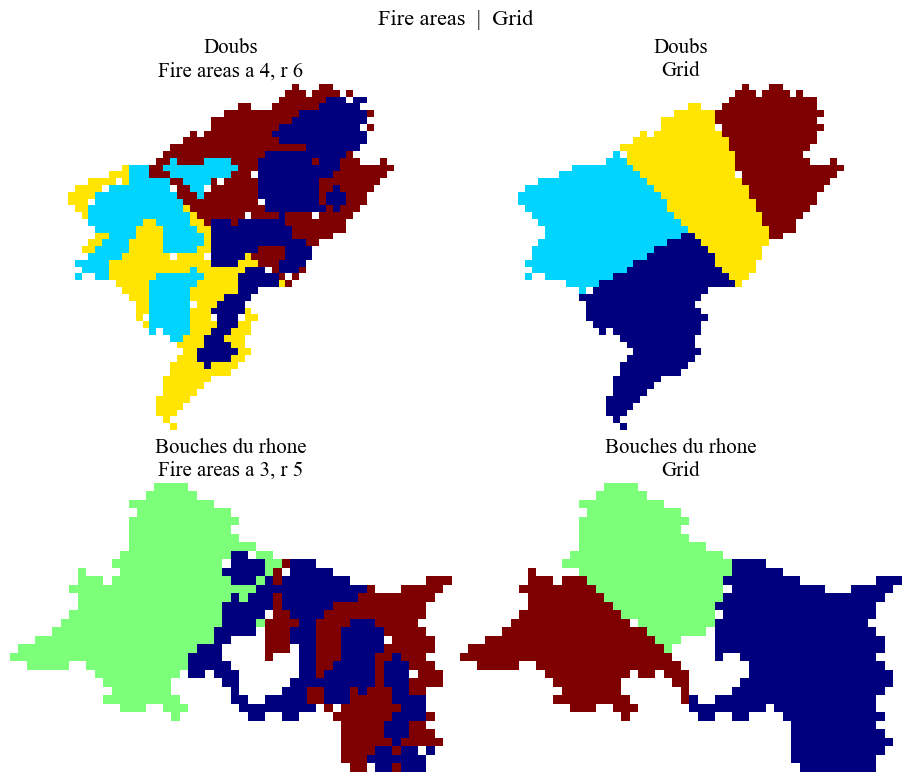

In [27]:
from matplotlib import font_manager as fm
url = "https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf"
!wget -q -O /home/caron/Bureau/TimesNewRoman.ttf {url}

fm.fontManager.addfont("/home/caron/Bureau/TimesNewRoman.ttf")
#fm._rebuild()                         # refresh in-memory cache

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"]  = ["Times New Roman"]

plt.rcParams.update({
    "font.family": "Times New Roman",   # use Times New Roman everywhere
    "font.size":   8,                   # default size for text
    # fine-grained control (optional but usually helpful)
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})
plot_two_layers_per_dept_2cols(dept_config_daily, dept_config_regular, cmap_fire='jet', cmap_grid='jet')